In [4]:
# ── Cell 1: Install dependencies ────────────────────────────
!pip install transformers datasets scikit-learn pandas torch matplotlib seaborn -q

In [5]:
# ── Cell 2: Imports ─────────────────────────────────────────
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)


In [6]:
# ── Cell 3: Check GPU ────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [7]:
import json
from google.colab import files

# Upload the JSON file
print("Please upload 'data_full.json' when prompted.")
uploaded = files.upload()

# Load the JSON file
with open("data_full.json", "r") as f:
    raw = json.load(f)

# Convert to pandas DataFrame
rows = []
for split in ['train', 'val', 'test']:
    for text, intent in raw[split]:
        rows.append({'issue_description': text, 'category': intent})

data = pd.DataFrame(rows)

print(data.head())
print(f"Dataset shape: {data.shape}")
print(f"Unique descriptions: {data['issue_description'].nunique()}")
print(f"Categories: {data['category'].nunique()}")

Please upload 'data_full.json' when prompted.


Saving data_full.json to data_full.json
                                   issue_description   category
0  what expression would i use to say i love you ...  translate
1  can you tell me how to say 'i do not speak muc...  translate
2  what is the equivalent of, 'life is good' in f...  translate
3  tell me how to say, 'it is a beautiful morning...  translate
4  if i were mongolian, how would i say that i am...  translate
Dataset shape: (22500, 2)
Unique descriptions: 22495
Categories: 150


In [8]:
# ── NEW Cell 4.5: Clean ───────────────────   ← ADD THIS
print("Before cleaning:", len(data))
print("Duplicates:", data.duplicated('issue_description').sum())
print("Nulls:", data['issue_description'].isnull().sum())

data = data.drop_duplicates(subset='issue_description')
data = data.dropna(subset=['issue_description', 'category'])
data = data[data['issue_description'].str.strip() != '']
data = data.reset_index(drop=True)   # reset row numbers after dropping

print("After cleaning:", len(data))

Before cleaning: 22500
Duplicates: 5
Nulls: 0
After cleaning: 22495


In [9]:
# ── Cell 5: Label Encoding ───────────────────────────────────
label_map = {label: i for i, label in enumerate(data['category'].unique())}
id2label = {i: label for label, i in label_map.items()}
data['label'] = data['category'].map(label_map)
print("Label map:", label_map)

num_labels = len(label_map)

Label map: {'translate': 0, 'transfer': 1, 'timer': 2, 'definition': 3, 'meaning_of_life': 4, 'insurance_change': 5, 'find_phone': 6, 'travel_alert': 7, 'pto_request': 8, 'improve_credit_score': 9, 'fun_fact': 10, 'change_language': 11, 'payday': 12, 'replacement_card_duration': 13, 'time': 14, 'application_status': 15, 'flight_status': 16, 'flip_coin': 17, 'change_user_name': 18, 'where_are_you_from': 19, 'shopping_list_update': 20, 'what_can_i_ask_you': 21, 'maybe': 22, 'oil_change_how': 23, 'restaurant_reservation': 24, 'balance': 25, 'confirm_reservation': 26, 'freeze_account': 27, 'rollover_401k': 28, 'who_made_you': 29, 'distance': 30, 'user_name': 31, 'timezone': 32, 'next_song': 33, 'transactions': 34, 'restaurant_suggestion': 35, 'rewards_balance': 36, 'pay_bill': 37, 'spending_history': 38, 'pto_request_status': 39, 'credit_score': 40, 'new_card': 41, 'lost_luggage': 42, 'repeat': 43, 'mpg': 44, 'oil_change_when': 45, 'yes': 46, 'travel_suggestion': 47, 'insurance': 48, 'todo

In [10]:
# ── Cell 6: Train/Test Split ─────────────────────────────────
train_texts, test_texts, train_labels, test_labels = train_test_split(
    data['issue_description'].astype(str),
    data['label'],
    test_size=0.2,
    random_state=42,
    stratify=data['label']          # ensures balanced split per class
)
print(f"Train size: {len(train_texts)}, Test size: {len(test_texts)}")

Train size: 17996, Test size: 4499


In [11]:
# ── Cell 7: Tokenisation ─────────────────────────────────────
from transformers import RobertaTokenizer, RobertaForSequenceClassification

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
# ── Cell 8: Dataset Class ────────────────────────────────────
class TicketDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Tokenize the input texts
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True)

train_dataset = TicketDataset(train_encodings, train_labels)
test_dataset  = TicketDataset(test_encodings,  test_labels)

In [13]:
# Cell 9 - Model
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label_map
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
# ── Cell 10: Metrics Function ────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

In [15]:
# ── Cell 11: Training Arguments (optimised for T4) ───────────
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,     # 16 fits comfortably in T4's 16 GB VRAM
    per_device_eval_batch_size=32,      # larger eval batch = faster evaluation
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,                          # mixed precision - cuts training time ~2x on T4
    dataloader_num_workers=2,
    report_to="none"                    # disable W&B to keep output clean
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [16]:
# ── Cell 12: Trainer & Train ─────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.288815,0.198907,0.964214
2,0.103765,0.133664,0.972883
3,0.056989,0.109488,0.979106


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=3375, training_loss=0.5811232680567988, metrics={'train_runtime': 322.3444, 'train_samples_per_second': 167.485, 'train_steps_per_second': 10.47, 'total_flos': 1027885690882512.0, 'train_loss': 0.5811232680567988, 'epoch': 3.0})

In [17]:
# ── Cell 13: Evaluate & Accuracy ────────────────────────────
predictions = trainer.predict(test_dataset)
preds = predictions.predictions.argmax(axis=1)
true_labels = test_labels.tolist()

accuracy = accuracy_score(true_labels, preds)
print(f"\n✅ Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


✅ Test Accuracy: 0.9791 (97.91%)


In [18]:
# ── Cell 14: Classification Report ──────────────────────────
label_names = [id2label[i] for i in range(num_labels)]
report = classification_report(true_labels, preds, target_names=label_names)
print("\n📊 Classification Report:\n")
print(report)



📊 Classification Report:

                           precision    recall  f1-score   support

                translate       1.00      1.00      1.00        30
                 transfer       1.00      1.00      1.00        30
                    timer       0.94      1.00      0.97        30
               definition       1.00      1.00      1.00        30
          meaning_of_life       1.00      1.00      1.00        30
         insurance_change       0.97      1.00      0.98        30
               find_phone       1.00      1.00      1.00        30
             travel_alert       1.00      1.00      1.00        30
              pto_request       0.97      1.00      0.98        30
     improve_credit_score       0.97      1.00      0.98        30
                 fun_fact       0.97      1.00      0.98        30
          change_language       0.97      1.00      0.98        30
                   payday       1.00      0.93      0.97        30
replacement_card_duration       1.

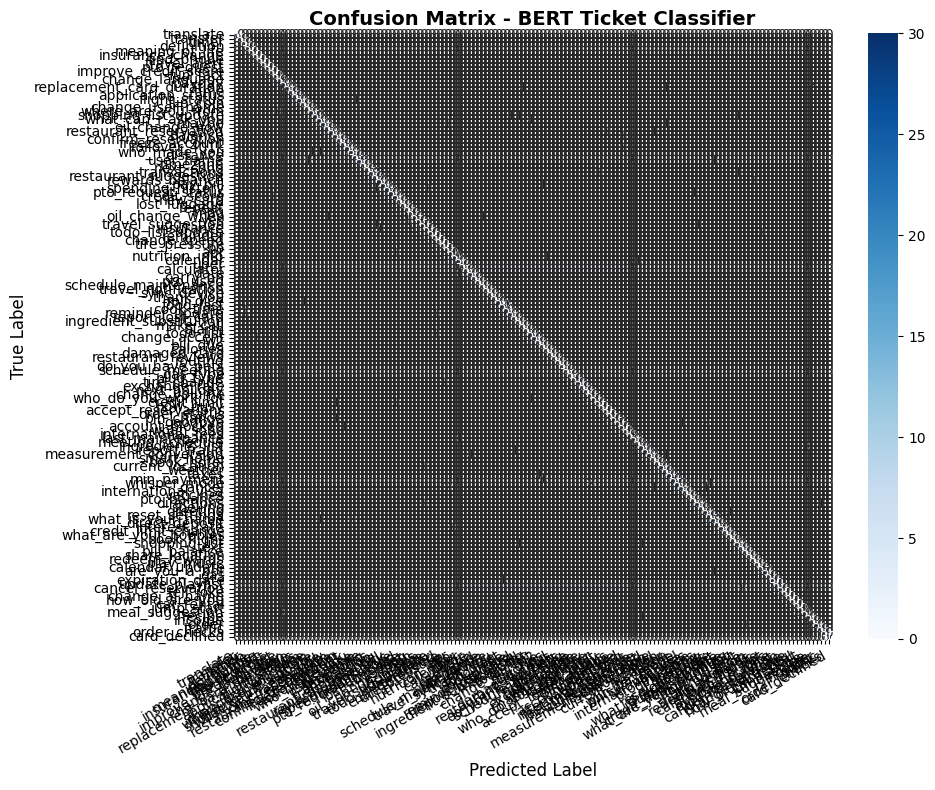

Confusion matrix saved as confusion_matrix.png


In [19]:
# ── Cell 15: Confusion Matrix ────────────────────────────────
cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title('Confusion Matrix - BERT Ticket Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

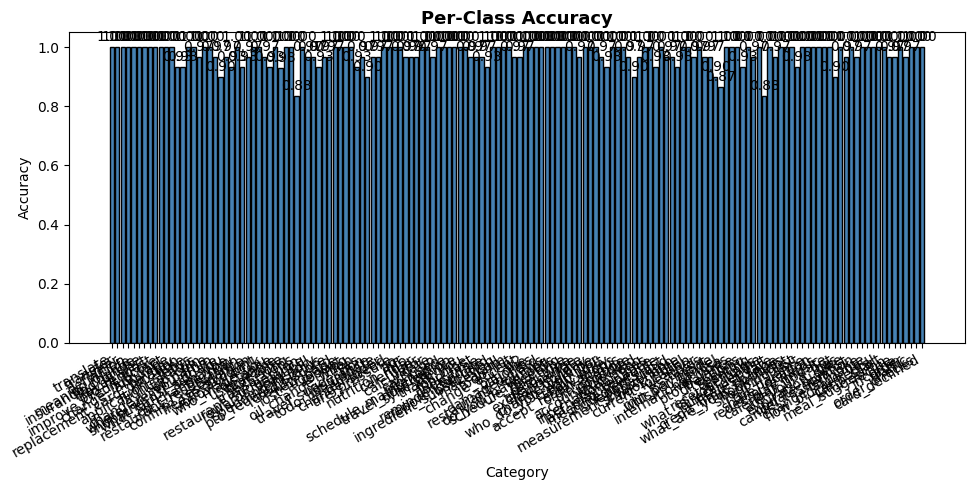

In [20]:
# ── Cell 16: Per-class Accuracy Bar Chart ────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 5))
bars = plt.bar(label_names, per_class_acc, color='steelblue', edgecolor='black')
plt.ylim(0, 1.05)
plt.title('Per-Class Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=150)
plt.show()

In [21]:
# ── Cell 17: Single Prediction Test ─────────────────────────
def predict_ticket(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                       padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
    pred_id = torch.argmax(outputs.logits).item()
    return id2label[pred_id]

test_ticket = "My internet connection is not working and pages won't load"
print(f"\nTest ticket: '{test_ticket}'")
print(f"Predicted Category: {predict_ticket(test_ticket)}")


Test ticket: 'My internet connection is not working and pages won't load'
Predicted Category: sync_device


In [22]:
# ── Cell 18: Save Model ──────────────────────────────────────
model.save_pretrained("ticket_model")
tokenizer.save_pretrained("ticket_model")
print("\nModel saved to ./ticket_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to ./ticket_model


In [23]:
# ── Final Cell: Save + Download everything ────────────────────
import shutil
import json
from google.colab import files

# Save model and tokenizer
model.save_pretrained("ticket_model")
tokenizer.save_pretrained("ticket_model")

# Save label maps
with open("ticket_model/label_map.json", "w") as f:
    json.dump(label_map, f)
with open("ticket_model/id2label.json", "w") as f:
    json.dump({str(k): v for k, v in id2label.items()}, f)

# Save metrics for dashboard
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import json

predictions_output = trainer.predict(test_dataset)
preds = predictions_output.predictions.argmax(axis=1)
true_labels_list = test_labels.tolist()

# Confusion matrix
cm = confusion_matrix(true_labels_list, preds)
label_names = [id2label[i] for i in range(num_labels)]

metrics = {
    "accuracy": float(accuracy_score(true_labels_list, preds)),
    "confusion_matrix": cm.tolist(),
    "label_names": label_names,
    "classification_report": classification_report(
        true_labels_list, preds,
        target_names=label_names,
        output_dict=True
    )
}

with open("ticket_model/metrics.json", "w") as f:
    json.dump(metrics, f)

print("Accuracy:", metrics["accuracy"])

# Zip and download
shutil.make_archive("ticket_model", "zip", "ticket_model")
files.download("ticket_model.zip")
print("Download started!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Accuracy: 0.9791064681040231


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!
